In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [3]:
import random
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
import tensorflow as tf

import pickle
import numpy as np

import string
import re
import math

### Methoden en Technieken (M&T), blok 2 - Les 3

Vorige week hebben we tekst-classificatie en taalmodellen geintroduceerd. Met het taalmodel hebben we tekst gegenereerd.

<br>

Deze les introduceren we seq2seq-learning en transformers. 

<br>

De inhoud is grotendeels gebaseerd op H15 uit [*Deep Learning with Python*](https://deeplearningwithpython.io/).<br>
De code komt grotendeels van<br>
[https://github.com/fchollet/deep-learning-with-python-notebooks](https://github.com/fchollet/deep-learning-with-python-notebooks)

### Sequence-to-sequence (seq2qseq) learning

* Een sequence-to-sequence-model beeldt een reeks af op een andere reeks.
* Van een bronreeks naar een doelreeks
* Van een stuk tekst (bron) naar een ander stuk tekst (doel)

:::: {.columns}
::: {.column width=60%}
In train-fase

* Maakt gebruik van een encoder en een decoder.
* De encoder zet de bronreeks in een tussenrepresentatie
* De decoder is een taalmodel (zoals in de vorige les)
:::
::: {.column width=40%}
![Fig. 15.1 uit [DLP]](Plaatjes\EncoderDecoderArchitectuur.png)
:::
::::

### seq2seq - voorspelling

:::: {.columns}
::: {.column width=60%}

- Start een nieuwe tekst met een start-symbool (''[start]'')
- Gebruik de gecodeerde oorspronkelijke tekst en alle voorgaande symbolen uit de nieuwe tekst om het volgende symbool te bepalen.
- Doe dit net zolang tot men een stop-symbool (''[stop]'') voorspelt.
:::
::: {.column width=40%}
![Fig. 15.1 uit [DLP]](Plaatjes\EncoderDecoderArchitectuur.png)
:::
::::

### Voorbeeld: Vertaal-opdracht Eng-Ned
Dataset: zie [https://www.manythings.org/anki/](https://www.manythings.org/anki/)

In [4]:
f = open('/Users/Ik/.keras/datasets/nldKlein.txt', 'r')
file_contents = f.read()
print (file_contents)
f.close()

Go.	Lopen!	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #7764436 (LinguisticFusion)
Go.	Vooruit.	CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #7915821 (Elsofie)
Hi.	Hoi.	CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #537889 (Dorenda)
Hi.	Hé!	CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #6117419 (Raizin)
Hi.	Hai!	CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #6117420 (Raizin)
Run!	Ren!	CC-BY 2.0 (France) Attribution: tatoeba.org #906328 (papabear) & #1569976 (Globetrotter)
Run!	Vlucht.	CC-BY 2.0 (France) Attribution: tatoeba.org #906328 (papabear) & #8227862 (meshbags)
Run.	Ren!	CC-BY 2.0 (France) Attribution: tatoeba.org #4008918 (JSakuragi) & #1569976 (Globetrotter)
Run.	Vlucht.	CC-BY 2.0 (France) Attribution: tatoeba.org #4008918 (JSakuragi) & #8227862 (meshbags)
This is my business card.	Dit is mijn visitekaartje.	CC-BY 2.0 (France) Attribution: tatoeba.org #2086218 (freddy1) & #4927287 (Raizin)
This is my email a

In [8]:
#| output: false

# lokaal uitvoeren
dname = os.path.join("/Users/Ik/.keras/datasets/")
fname = os.path.join(dname, "nld-eng/nld.txt")

with open(fname, encoding="utf8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = []

for line in lines:
    english, spanish, rest = line.split("\t")
    spanish = "[start] " + spanish + " [end]"
    text_pairs.append((english, spanish))

In [9]:
#| output: false
'''# Voor COLAB deze en de volgende cel uitvoeren
from google.colab import files
uploaded = files.upload()'''

'# Voor COLAB deze en de volgende cel uitvoeren\nfrom google.colab import files\nuploaded = files.upload()'

In [10]:
#| output: false

'''text_file = "nld.txt"
with open(text_file, encoding='utf8') as f:
    lines = f.read().split("\n")[:-1]
text_pairs = []
for line in lines:
    english, spanish, rest = line.split("\t")
    spanish = "[start] " + spanish + " [end]"
    text_pairs.append((english, spanish))'''


'text_file = "nld.txt"\nwith open(text_file, encoding=\'utf8\') as f:\n    lines = f.read().split("\n")[:-1]\ntext_pairs = []\nfor line in lines:\n    english, spanish, rest = line.split("\t")\n    spanish = "[start] " + spanish + " [end]"\n    text_pairs.append((english, spanish))'

### Vertaal-opdracht, datapreparatie
Laad de data in en maak paren zoals

In [11]:
random.seed(1407)
print(random.choice(text_pairs))

('Which tooth hurts?', '[start] Welke tand doet pijn? [end]')


In [12]:
random.seed(1407)
random.shuffle(text_pairs)
val_samples = int(0.15 * len(text_pairs))
train_samples = len(text_pairs) - 2 * val_samples
train_pairs = text_pairs[:train_samples]
val_pairs = text_pairs[train_samples : train_samples + val_samples]
test_pairs = text_pairs[train_samples + val_samples :]

- vectorizeren
    - We halen leestekens weg (maar behouden `[` en `]`)
    - De 15.000 meest-gebruikte woorden (in elke taal)
    - Een zin is hoogstens 20 woorden (in elke taal)

Merk op dat in een werkelijke vertaalopdracht leestekens wel van belang kunnen zijn. Men behandeld de afzonderlijke leestekens dan als symbolen (*tokens*).<br>

Maak input-output paren.

In [13]:
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", ""
    )

vocab_size = 15000
sequence_length = 20

english_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)
spanish_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)
train_english_texts = [pair[0] for pair in train_pairs]
train_spanish_texts = [pair[1] for pair in train_pairs]
english_tokenizer.adapt(train_english_texts)
spanish_tokenizer.adapt(train_spanish_texts)

In [14]:
batch_size = 64

def format_dataset(eng, spa):
    eng = english_tokenizer(eng)
    spa = spanish_tokenizer(spa)
    features = {"english": eng, "spanish": spa[:, :-1]}
    labels = spa[:, 1:]
    sample_weights = labels != 0
    return features, labels, sample_weights

def make_dataset(pairs):
    eng_texts, spa_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    spa_texts = list(spa_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, spa_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=4)
    return dataset.shuffle(2048).cache()

train_ds = make_dataset(train_pairs)
val_ds = make_dataset(val_pairs)

In [15]:
#random.seed(1407)

eng_vocab = english_tokenizer.get_vocabulary()
eng_index_lookup = dict(zip(range(len(eng_vocab)), eng_vocab))

spa_vocab = spanish_tokenizer.get_vocabulary()
spa_index_lookup = dict(zip(range(len(spa_vocab)), spa_vocab))

for inputs, targets, rest in train_ds.take(1):
    source_sentence = " ".join(eng_index_lookup[int(i)] for i in inputs['english'][1,])
    target_input_sentence = " ".join(spa_index_lookup[int(i)] for i in inputs['spanish'][1,])
    target_output_sentence = " ".join(spa_index_lookup[int(i)] for i in targets[1,])
    [print("input : ("+str(source_sentence)+","+str(target_input_sentence)+")"),
     print("output : "+str(target_output_sentence))]

input : (who are you                 ,[start] wie zijn jullie [end]               )
output : wie zijn jullie [end]                


### seq2seq, klassieke manier

* Populair rond 2015-2017 (tot Transformer het overnam).
* Naief zou men het volgende kunnen doen (`return_sequences=True`)
* Vertaalde zin is even lang als de te vertalen zin.<br>
Niet realistisch, maar op te lossen met padding.
* Maakt gebruik van de eerste $N$ symbolen uit de oorspronkelijke tekst om het $N$-de symbool van de nieuwe tekst te voorspellen.<br>
Je zou gebruik willen maken van de gehele oorspronkelijke tekst.
* Dit laatste is wat een encoder-decoder oplost.

In [16]:
inputs = keras.Input(shape=(sequence_length,), dtype="int32")
x = layers.Embedding(input_dim=vocab_size, output_dim=128)(inputs)
x = layers.LSTM(32, return_sequences=True)(x)
outputs = layers.Dense(vocab_size, activation="softmax")(x)
model = keras.Model(inputs, outputs, name="Klassiek")
model.summary()

Model: "Klassiek"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 20, 128)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20, 15000)      │       495,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,608 (9.29 MB)

 Trainable params: 2,435,608 (9.29 MB)

 Non-trainable params: 0 (0.00 B)

### seq2seq, RNN-encoder-decoder

<br>

![Fig. 15.2 uit [DLP]](Plaatjes\EncoderDecoderGRUarchitectuur.png)

<br>

We zullen de gecodeerde source sentence als *initial state* gebruiken voor de decoder (GRU-laag).

<br>
<br>


### seq2seq, RNN-encoder-decoder-model

In [17]:
embed_dim = 256
hidden_dim = 1024

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(source)
rnn_layer = layers.GRU(hidden_dim)
rnn_layer = layers.Bidirectional(rnn_layer, merge_mode="sum")
encoder_output = rnn_layer(x)

target = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(target)
rnn_layer = layers.GRU(hidden_dim, return_sequences=True)
x = rnn_layer(x, initial_state=encoder_output)
x = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
seq2seq_rnn = keras.Model([source, target], target_predictions)

seq2seq_rnn.summary(100)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ english (InputLayer)        │ (None, None)            │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ spanish (InputLayer)        │ (None, None)            │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ embedding_1 (Embedding)     │ (None, None, 256)       │      3,840,000 │ english[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ not_equal (NotEqual)        │ (None, None)            │              0 │ english[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ embedding_2 (Embedding)     │ (None, None, 256)       │      3,840,000 │ spanish[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bidirectional               │ (None, 1024)            │      7,876,608 │ embedding_1[0][0],      │
│ (Bidirectional)             │                         │                │ not_equal[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ gru_1 (GRU)                 │ (None, None, 1024)      │      3,938,304 │ embedding_2[0][0],      │
│                             │                         │                │ bidirectional[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout (Dropout)           │ (None, None, 1024)      │              0 │ gru_1[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dense_1 (Dense)             │ (None, None, 15000)     │     15,375,000 │ dropout[0][0]           │
└─────────────────────────────┴─────────────────────────┴────────────────┴─────────────────────────┘

 Total params: 34,869,912 (133.02 MB)

 Trainable params: 34,869,912 (133.02 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#| output: false
'''seq2seq_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

history = seq2seq_rnn.fit(train_ds,
                    epochs=15,
                    validation_data=val_ds)
# 20 minuten per epoch op laptop met cpu
# 2 minuten per epoch op Colab met GPU

seq2seq_rnn.save('models/seq2seq_rnn.keras')
with open('models/seq2seq_rnn.hist', 'wb') as file:
    pickle.dump(history.history, file)'''

'seq2seq_rnn.compile(\n    optimizer="adam",\n    loss="sparse_categorical_crossentropy",\n    weighted_metrics=["accuracy"],\n)\n\nhistory = seq2seq_rnn.fit(train_ds,\n                    epochs=15,\n                    validation_data=val_ds)\n# 20 minuten per epoch op laptop met cpu\n# 2 minuten per epoch op Colab met GPU\n\nseq2seq_rnn.save(\'models/seq2seq_rnn.keras\')\nwith open(\'models/seq2seq_rnn.hist\', \'wb\') as file:\n    pickle.dump(history.history, file)'

In [19]:
def laad_geschiedenis(naam):
    with open("models/"+naam+".hist", 'rb') as file:
        history = pickle.load(file)
    return history

def afbeelding(naam):
    geschiedenis = laad_geschiedenis(naam)
    accuracy = geschiedenis["accuracy"]
    val_accuracy = geschiedenis["val_accuracy"]
    epochs = range(1, len(accuracy) + 1)
    plt.figure()
    plt.plot(epochs, accuracy, "b-", label="Training")
    plt.plot(epochs, val_accuracy, "y-", label="Validatie")
    #plt.plot(epochs, [0.5]*len(epochs), 'r--', label='Nulmodel')
    plt.xlabel('Epochs')
    plt.ylabel('accuraatheid')
    plt.title("Training- and validatie-accuraatheid, "+naam)
    plt.legend()
    plt.show()

### seq2seq met RNN, training

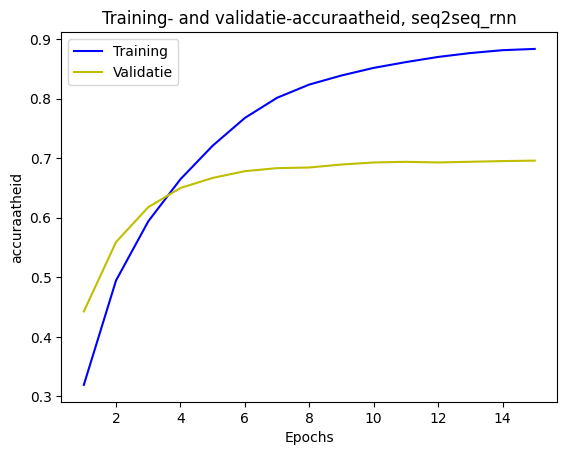

In [20]:
afbeelding("seq2seq_rnn")

In [21]:
seq2seq_rnn = keras.models.load_model("models/seq2seq_rnn.keras")

### Hoe vertalingen beoordelen?
In deze simpele situatie gebruiken we accuraatheid (op het voorspellen van het volgende woord).

Geen realistische maat voor de werkelijkheid

Typische prestatiematen zijn (varianten van) de BLEU-scores (*bilingual evaluation understudy*).

### seq2seq met RNN, resultaat

In [22]:
dut_vocab = spanish_tokenizer.get_vocabulary()
dut_index_lookup = dict(zip(range(len(dut_vocab)), dut_vocab))
max_decoded_sentence_length = 20

def decode_sequence(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])
        next_token_predictions = seq2seq_rnn.predict(
            [tokenized_input_sentence, tokenized_target_sentence], verbose=0)
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = dut_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence


In [23]:
zinnen = ["I heard it through the grapevine",
          "Sitting on the dock of the bay",
          "After laughter comes tears",
          "Do you like good music",
          "Stop, in the name of love",
          "I say a little prayer",
          "Ain't no mountain high enough",
          "you don't have to say you love me"]

m = len(max(zinnen, key=len))
for i in zinnen:
    j = math.ceil((m - len(i)-1)/8)+1
    tab = "".join(np.repeat("\t",j))
    print(i+tab+"-->" + "\t"+decode_sequence(i))

I heard it through the grapevine	-->	[start] ik hoorde het de geluid [end]
Sitting on the dock of the bay		-->	[start] neem de schade aan de fles [end]
After laughter comes tears		-->	[start] nadat ze het lessen wordt [end]
Do you like good music			-->	[start] hou je van goed muziek [end]
Stop, in the name of love		-->	[start] stop in de liefde van de natte stem [end]
I say a little prayer			-->	[start] ik zegt dat een beetje hard [end]
Ain't no mountain high enough		-->	[start] is niet echt genoeg getrouwd [end]
you don't have to say you love me	-->	[start] je hoeft je niet te vertellen [end]


### Nadelen van RNN-sequence-to-sequence

- De hele zin moet in de toestandsvector(en) van de encoder staan. Dit geeft een beperking op de lengte en de complexiteit van de zinnen (die je kan vertalen).
- Hoewel een RNN gebruikmaakt van geheugen zal dat niet een zeer lange termijn geheugen zijn. De context van een tekst kan met RNN's niet over een lang stuk tekst bewaard worden.
- Een oplossing hiervoor is iets wat we *attention* (aandacht) noemen
- Het idee van attention is dat niet alle variabelen altijd evenveel gewicht nodig hebben. Voorbeelden:
- max pooling<br>
Slechts 1 variabele uit een gebied wordt gebruikt in het model
- tf-idf-normalisatie<br>
Elke variabele wordt gewogen naar hoe vaak het voorkomt in de tekst en in alle teksten

### Attention in NLP
- Niet elk symbool (token) van de tekst zal even belangrijk zijn.
- Sommige variabelen zullen we meer aandacht willen geven.
- Dit doen we door scores per variabele te berekenen.

De scores zullen context meegeven aan de tekst. Wat is de betekenis van "tent" in onderstaande zinnen (en hoe weten/zien we dat)?

- In een tent slaapt het fijner met een matje of een matras
- In deze tent serveren ze slechte koffie
- In deze tent is de garderobe verplicht

### Attention is all you need

- Ashish Vaswani et al., “Attention is all you need” (2017), [https://arxiv.org/abs/1706.03762](https://arxiv.org/abs/1706.03762).
- In dit artikel beargumenteren de schrijvers dat attention het *enige* is wat nodig is voor een succesvol sequence-model in NLP. Dus geen RNN's meer.
- Het idee dat zij introduceren is een encoder-decoder model dat gebruikmaakt van attention: de transformer.
- Heeft vanaf 2022 veel aandacht gekregen vanwege ChatGPT.


### Self-attention
Geef voor elk symbool $X$ in de tekst weer hoeveel aandacht elk symbool $Y$ in de tekst moet krijgen om $X$ beter te "begrijpen" (betere positie in de word-embedding te geven).

Welke woorden $Y$ zijn nodig om per woord $X$ dat woord $X$ te begrijpen in de volgende zin.

- In een tent slaapt het fijner met een matje of een matras

Welke woorden zouden kunnen helpen bij het beter positioneren van "tent" in de inbedding?

### Self-attention, gevisualiseerd

<br>

![Fig. 11.6 uit [DLP, 2de editie]](Plaatjes\SelfAttention.png)

### Hoe wordt self-attention bepaald?

* Vorige les hebben we uitgelegd dat we in NLP gebruikmaken van word-embeddings.
* Het idee is dat in een word-embedding de dimensies zo bepaald worden dat ze een betekenis hebben.
* Woorden die niets met elkaar te maken hebben (in betekenis) zullen loodrecht op elkaar staan, terwijl woorden die op elkaar lijken (in betekenis) ongeveer in dezelfde richting zullen wijzen.

In hoeverre twee vectoren in dezelfde richting staan wordt bepaald door het inproduct (dot product).

### Self-attention met inproduct

Het inproduct (dot product) van twee vectoren varieert tussen een minimum $-M$ en een maximum $M$.

- $-M$ als de vectoren precies de andere kant opwijzen.
- Nul als de vectoren loodrecht op elkaar staan.
- $M$ als de vectoren in dezelfde richting staan.

Elk woord wordt nu in de richting geschoven van elk ander woord in de tekst. Hoeveel we schuiven hangt af van het inproduct met dat woord.

$$
\texttt{nieuw woord} = f(\texttt{oud woord}) = \sum_{\texttt{woord} \in \texttt{tekst}}\texttt{inproduct}(\texttt{oud woord}, \texttt{woord}) * \texttt{woord}
$$

### Self-attention in $\texttt{Keras}$ - [**keras.layers.MultiHeadAttention**](https://keras.io/api/layers/attention_layers/multi_head_attention/)

![Fig. 11.8 uit [DLP, 2de editie]](Plaatjes\MultipleHeads.png)

### Waarom Query, Key en Value?

* We willen elk symbool in een tekst vergelijken met elk ander symbool in de tekst om daar een nieuwe representatie van de tekst voor te maken.
* We maken gebruik van
$$
\sum_{\texttt{woord} \in \texttt{tekst}}\texttt{inproduct}(\texttt{oud woord}, \texttt{woord}) * \texttt{woord}
$$
* De drie woord-termen in bovenstaande uitdrukking, zouden allemaal anders kunnen zijn:
$$
\sum\texttt{inproduct}(\texttt{query}, \texttt{key}) * \texttt{value}
$$ 
Vergelijk dit met het query-key-value-model (volgende slide).
* Attention wordt niet alleen gebruikt voor self-attention

### Vergelijk met het query-key-value-model

![Fig. 15.6 uit [DLP]](Plaatjes/QueryKeyValue.png)

### Waarom die dense-lagen?

* De dense-lagen maken de hypothese-ruimte groter
* De lagen zouden ervoor kunnen zorgen dat woorden met dezelfde betekenis in een andere taal in dezelfde richting staan


### Instellingen van de multihead attention

*"The “Attention is all you need” authors made two more changes to our mechanism through trial and error."*

* Verschillende koppen
* Herschaling

<br>

* Wat betekent dit (*trial and error*)?
* Wie mag dit zeggen?

### Waarom verschillende koppen?

Veschillende koppen kunnen zich op verschillende zaken concentreren.

![Fig. 15.7 uit [DLP]](Plaatjes/multi-head-attention.png)

### Herschaling van de uitvoer

* We nemen het inproduct tussen (lange) vectoren wat ervoor kan zorgen dat de uitvoer groot kan worden
* Om dit te voorkomen delen we het inproduct door de wortel van de lengte van de $\texttt{source}$ (key)
* De uitvoer kan nog steeds groot worden (afhankelijk van de $\texttt{target}$ (query) en de hoeveelheid attention)
* Men zorgt ervoor dat de som van alle attention (voor een $\texttt{target}$) gelijk is aan 1


### Transformer encoder

![Fig. 11.9 uit [DLP, 2de editie]](Plaatjes\TransformerEncoder.png)

In [24]:
class TransformerEncoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, **kwargs):
        super().__init__()
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.self_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()

    def call(self, source, source_mask):
        residual = x = source
        mask = source_mask[:, None, :]
        x = self.self_attention(query=x, key=x, value=x, attention_mask=mask)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

### [**keras_nlp.layers.TransformerEncoder**](https://keras.io/keras_hub/api/modeling_layers/transformer_encoder/)

- Multihead laag<br>
Attention
- Dense projecties (met niet-lineaire activatie)<br>
Om het model flexibeler te maken
- Residual connecties<br>
Om informatie uit diepere lagen te behouden
- Normalisatielaag<br>
Nuttig bij diepe netwerken

Transformer encoder: classificatie

### De Transformer, idee
- De Transformer bestaat ook uit een encoder en een decoder.
- De encoder zorgt voor een representatie van de woorden waarin rekening wordt gehouden met attention en met volgorde.
- De uitvoer van de encoder is een sequence van woorden in een representatie.
- De decoder heeft als invoer de eerste $N$ woorden van de vertaalde zin en de representatie van de te vertalen zin.
- De decoder maakt gebruik van attention tussen de vertaalde zin en de te vertalen zin.
- Omdat je niet wil dat de decoder voorspelt aan de hand van "toekomstige" woorden, zullen we tijdens training gebruikmaken van *causal masking*.

### Volgorde toevoegen
Volgorde kan toegevoegd worden door woordpositie als integer-variabele mee te geven.

Verstandig om deze variabele te herschalen. Dat kan op verschillende manieren.

Kan ook via positional-embedding (zie [**keras_hub.layers.PositionEmbedding**](https://keras.io/keras_hub/api/modeling_layers/position_embedding/)).

### De Transformer, architectuur
![Fig. 11.14 uit [DLP, 2de editie]](Plaatjes\TheTransformerArchitectuur.png)

### De transformer, training

In [25]:
class TransformerDecoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, **kwargs):
        super().__init__()
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.self_attention_layernorm = layers.LayerNormalization()
        self.cross_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.cross_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()

    def call(self, target, source, source_mask):
        residual = x = target
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x
        mask = source_mask[:, None, :]
        x = self.cross_attention(
            query=x, key=source, value=source, attention_mask=mask
        )
        x = x + residual
        x = self.cross_attention_layernorm(x)
        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

In [26]:
class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__()
        self.token_embeddings = layers.Embedding(input_dim, output_dim)
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs):
        positions = ops.cumsum(ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

In [27]:
hidden_dim = 256
intermediate_dim = 2056
num_heads = 8

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)(source)
encoder_output = TransformerEncoder(hidden_dim, intermediate_dim, num_heads)(
    source=x,
    source_mask=source != 0,
)

target = keras.Input(shape=(None,), dtype="int32", name="spanish")
x = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)(target)
x = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(
    target=x,
    source=encoder_output,
    source_mask=source != 0,
)
x = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)
transformer = keras.Model([source, target], target_predictions)

In [ ]:
#| output: false
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"])

'''history = transformer.fit(train_ds,
                    epochs=2, # was 30
                    validation_data=val_ds)

# tussen de 7 en 8 minuten per epoch op laptop met cpu
# tussen de 40 en 50 seconden per epoch op Colab met GPU

# lokaal
transformer.save('models/transformer_versie3.keras')
with open('models/transformer_versie3.hist', 'wb') as file:
    pickle.dump(history.history, file)'''

'''# COLAB
transformer.save('transformer_COLAB.keras')
with open('transformer_COLAB.hist', 'wb') as file:
    pickle.dump(history.history, file)

from google.colab import files

files.download("transformer_COLAB.keras")
files.download("transformer_COLAB.hist")'''

'# COLAB\ntransformer.save(\'transformer_COLAB.keras\')\nwith open(\'transformer_COLAB.hist\', \'wb\') as file:\n    pickle.dump(history.history, file)\n\nfrom google.colab import files\n\nfiles.download("transformer_COLAB.keras")\nfiles.download("transformer_COLAB.hist")'

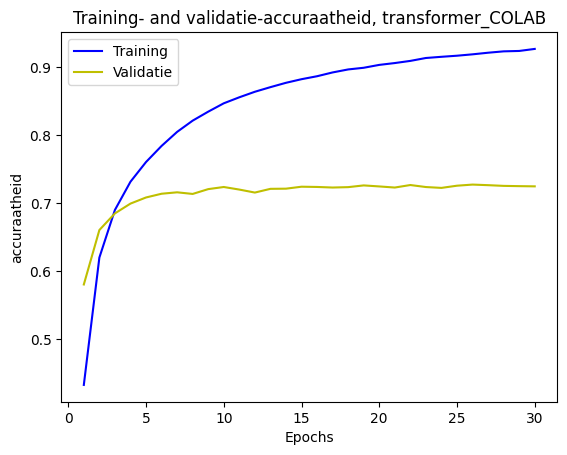

In [29]:
afbeelding("transformer_COLAB")

### De transformer, resultaat

In [33]:
#| output: false
'''transformer_recon = keras.models.load_model(transformer_pad,
                                            custom_objects={"PositionalEmbedding": PositionalEmbedding,
                                                           "TransformerEncoder": TransformerEncoder,
                                                           "TransformerDecoder": TransformerDecoder})'''
transformer_recon = keras.models.load_model("models/transformer_COLAB.keras",
                                            custom_objects={"PositionalEmbedding": PositionalEmbedding,
                                                           "TransformerEncoder": TransformerEncoder,
                                                           "TransformerDecoder": TransformerDecoder})
transformer_recon.summary()

c:\Users\Ik\anaconda3\envs\MenT2526\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Ik\anaconda3\envs\MenT2526\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Ik\anaconda3\envs\MenT2526\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()`

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spanish             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, None, 256) │  1,319,176 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ spanish[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │  1,582,856 │ transformer_enco… │
│ (TransformerDecode… │                   │            │ not_equal_1[0][0… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, None, 256) │          0 │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None,      │  3,855,000 │ dropout_3[0][0]   │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,341,818 (165.34 MB)

 Trainable params: 14,447,272 (55.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,894,546 (110.22 MB)

In [31]:

def decode_sequence(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])
        next_token_predictions = transformer_recon.predict(
            [tokenized_input_sentence, tokenized_target_sentence], verbose=0)
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = dut_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

def generate_translation(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(sequence_length):
        tokenized_target_sentence = spanish_tokenizer([decoded_sentence])
        tokenized_target_sentence = tokenized_target_sentence[:, :-1]
        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        next_token_predictions = transformer_recon.predict(inputs, verbose=0)
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = spa_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

In [32]:
for i in zinnen:
    j = math.ceil((m - len(i)-1)/8)+1
    tab = "".join(np.repeat("\t",j))
    print(i+tab+"-->" + "\t"+generate_translation(i))

I heard it through the grapevine	-->	[start] ik heb het door de afwas gehoord [end]
Sitting on the dock of the bay		-->	[start] doe de baai in de baai [end]
After laughter comes tears		-->	[start] na lachen zullen fruit [end]
Do you like good music			-->	[start] hou je van muziek [end]
Stop, in the name of love		-->	[start] hou op de naam van de naam [end]
I say a little prayer			-->	[start] ik zeg een beetje onscherp [end]
Ain't no mountain high enough		-->	[start] is geen berg snel genoeg [end]
you don't have to say you love me	-->	[start] je hoeft je niet te zeggen [end]
